In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_PATH = "zomato.csv"

In [2]:
df_raw = pd.read_csv(RAW_PATH)

print("Raw shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nMissing values per column:\n", df_raw.isnull().sum())
df_raw.head()

Raw shape: (56252, 13)

Columns: ['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']

Missing values per column:
 address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
valid_binary = {"Yes", "No"}

is_valid_online   = df_raw["online_order"].isin(valid_binary)
is_valid_book     = df_raw["book_table"].isin(valid_binary)
is_valid_votes    = pd.to_numeric(df_raw["votes"], errors="coerce").notna()

row_is_clean = is_valid_online & is_valid_book & is_valid_votes

print(f"Dropping {(~row_is_clean).sum()} corrupted rows "f"({(~row_is_clean).mean():.1%} of data)")

df = df_raw.loc[row_is_clean].copy()
print("Clean shape:", df.shape)

Dropping 4535 corrupted rows (8.1% of data)
Clean shape: (51717, 13)


In [4]:
# Rating: "4.1/5", "3.9 /5", "NEW", "-" -> float or NaN
df["rating"] = df["rate"].astype(str).str.extract(r"(\d\.\d)")[0].astype(float)

# Votes: already numeric strings
df["votes"] = pd.to_numeric(df["votes"], errors="coerce").astype("Int64")

# Cost for two (INR): strip thousands-separator commas -> float
df["cost_for_two"] = pd.to_numeric(df["approx_cost(for two people)"].astype(str).str.replace(",", "", regex=False),errors="coerce")

# Text field cleanup: strip whitespace, normalize case-sensitive dupes
for col in ["name", "location", "rest_type", "cuisines", "dish_liked", "listed_in(type)"]:
    df[col] = df[col].astype(str).str.strip()
    df.loc[df[col].isin(["nan", ""]), col] = np.nan

df.rename(columns={"listed_in(type)": "listing_type"}, inplace=True)

# Drop rows with no rating (can't be used in rating analysis) but keep a separate frame for volume-based analysis (e.g. cuisine popularity)
df_rated = df.dropna(subset=["rating"]).copy()

print(f"Rows with a usable rating: {len(df_rated)} / {len(df)}")
print(df[["rating", "votes", "cost_for_two"]].describe())

Rows with a usable rating: 41665 / 51717
             rating       votes  cost_for_two
count  41665.000000     51717.0  51371.000000
mean       3.700449  283.697527    555.431566
std        0.440513  803.838853    438.850728
min        1.800000         0.0     40.000000
25%        3.400000         7.0    300.000000
50%        3.700000        41.0    400.000000
75%        4.000000       198.0    650.000000
max        4.900000     16832.0   6000.000000


In [5]:
df_restaurants = df_rated.drop_duplicates(subset=["name", "address"]).copy()

print("Listing-level rows (rated):", len(df_rated))
print("Unique restaurants (rated):", len(df_restaurants))

Listing-level rows (rated): 41665
Unique restaurants (rated): 9507


In [6]:
cuisine_long = (df_rated.assign(cuisine=df_rated["cuisines"].str.split(",")).explode("cuisine"))
cuisine_long["cuisine"] = cuisine_long["cuisine"].str.strip()
cuisine_long = cuisine_long.dropna(subset=["cuisine"])

print("Total (restaurant, cuisine) pairs:", len(cuisine_long))
cuisine_long["cuisine"].value_counts().head(15)

Total (restaurant, cuisine) pairs: 106467


cuisine
North Indian    17406
Chinese         13005
South Indian     6394
Fast Food        6360
Continental      5245
Biryani          5071
Cafe             4828
Desserts         4537
Beverages        3873
Italian          3213
Street Food      2233
Bakery           2029
Pizza            1900
Burger           1869
Seafood          1662
Name: count, dtype: int64

Top 10 highest-rated cuisines (min 50 listings):
               avg_rating  n_listings
cuisine                              
Modern Indian    4.308276         145
Malaysian        4.306422         109
Japanese         4.258235         340
Mediterranean    4.213187         546
Konkan           4.170370          81
European         4.165793         687
Korean           4.149645         141
Asian            4.135631        1204
Burmese          4.107273          55
French           4.091892          74

Bottom 10 lowest-rated cuisines (min 50 listings):
                  avg_rating  n_listings
cuisine                                 
Chinese             3.611503       13005
Arabian             3.610895         927
South Indian        3.606662        6394
Kerala              3.601253        1197
Andhra              3.600878        1481
Oriya               3.565000         120
Biryani             3.554250        5071
Rolls               3.528425        1168
Charcoal Chicken    3.524194     

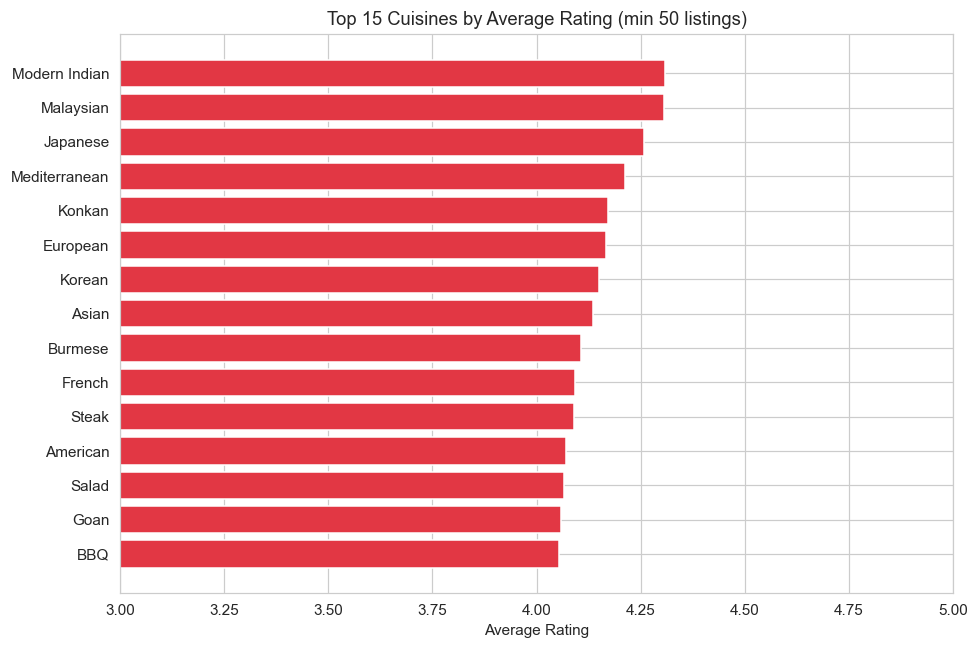

In [7]:
MIN_LISTINGS = 50  # ignore rare cuisines for a fair average

cuisine_stats = (cuisine_long.groupby("cuisine").agg(avg_rating=("rating", "mean"), n_listings=("rating", "size")).query("n_listings >= @MIN_LISTINGS").sort_values("avg_rating", ascending=False))

print("Top 10 highest-rated cuisines (min 50 listings):")
print(cuisine_stats.head(10))
print("\nBottom 10 lowest-rated cuisines (min 50 listings):")
print(cuisine_stats.tail(10))

fig, ax = plt.subplots(figsize=(9, 6))
top15 = cuisine_stats.head(15).sort_values("avg_rating")
ax.barh(top15.index, top15["avg_rating"], color="#e23744")
ax.set_xlabel("Average Rating")
ax.set_title("Top 15 Cuisines by Average Rating (min 50 listings)")
ax.set_xlim(3, 5)
plt.tight_layout()
plt.savefig("cuisine_vs_rating.png")
plt.show()

Top 10 locations by restaurant count:
                   n_restaurants  avg_rating
location                                    
Whitefield                   631    3.596197
BTM                          538    3.557621
HSR                          529    3.640454
Marathahalli                 514    3.524319
Electronic City              458    3.472271
Indiranagar                  446    3.783632
JP Nagar                     388    3.634794
Bannerghatta Road            355    3.474648
Jayanagar                    313    3.765176
Bellandur                    274    3.495620


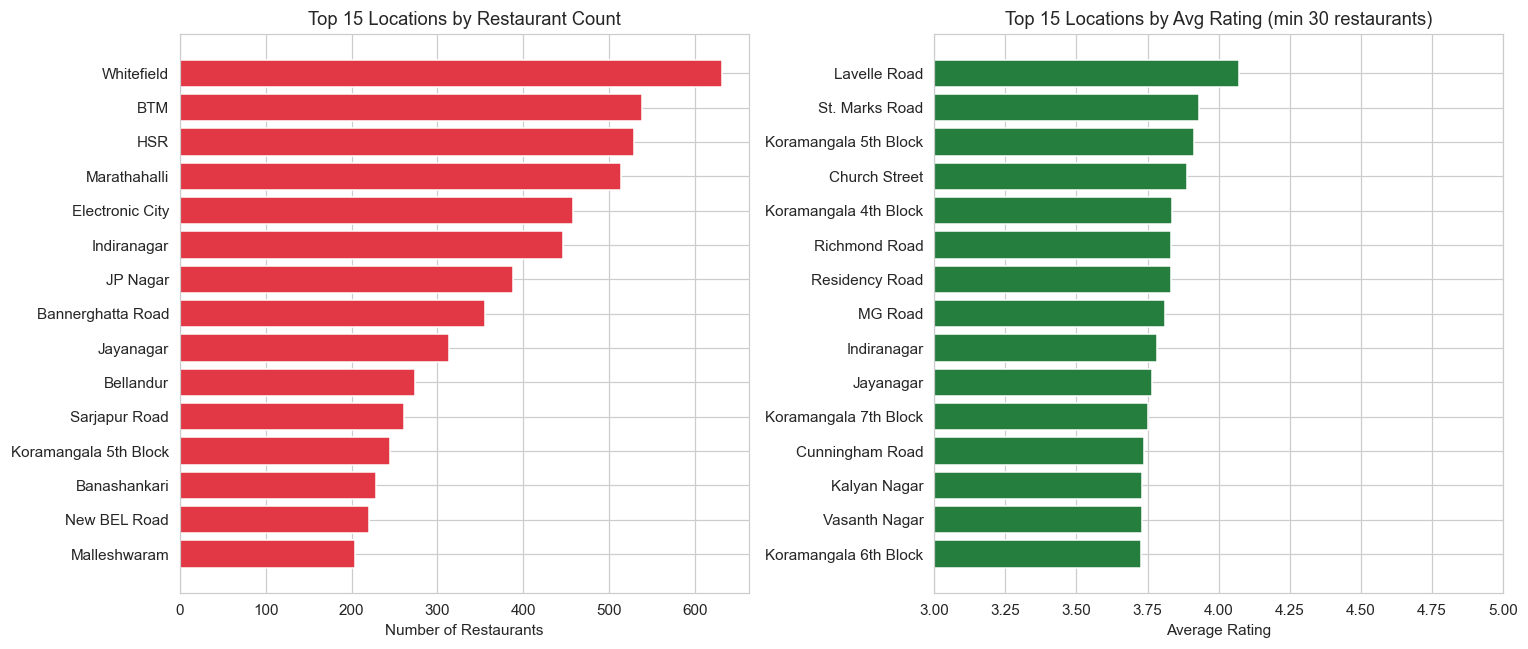

In [8]:
location_stats = (df_restaurants.groupby("location").agg(n_restaurants=("name", "size"), avg_rating=("rating", "mean")).sort_values("n_restaurants", ascending=False))

print("Top 10 locations by restaurant count:")
print(location_stats.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_by_count = location_stats.head(15).sort_values("n_restaurants")
axes[0].barh(top_by_count.index, top_by_count["n_restaurants"], color="#e23744")
axes[0].set_title("Top 15 Locations by Restaurant Count")
axes[0].set_xlabel("Number of Restaurants")

best_rated = location_stats[location_stats["n_restaurants"] >= 30] \
    .sort_values("avg_rating", ascending=False).head(15).sort_values("avg_rating")
axes[1].barh(best_rated.index, best_rated["avg_rating"], color="#267e3e")
axes[1].set_title("Top 15 Locations by Avg Rating (min 30 restaurants)")
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(3, 5)

plt.tight_layout()
plt.savefig("location_hotspots.png")
plt.show()

Correlation matrix:
                 rating    votes  cost_for_two
rating        1.000000  0.43404      0.385183
votes         0.434040  1.00000      0.366700
cost_for_two  0.385183  0.36670      1.000000


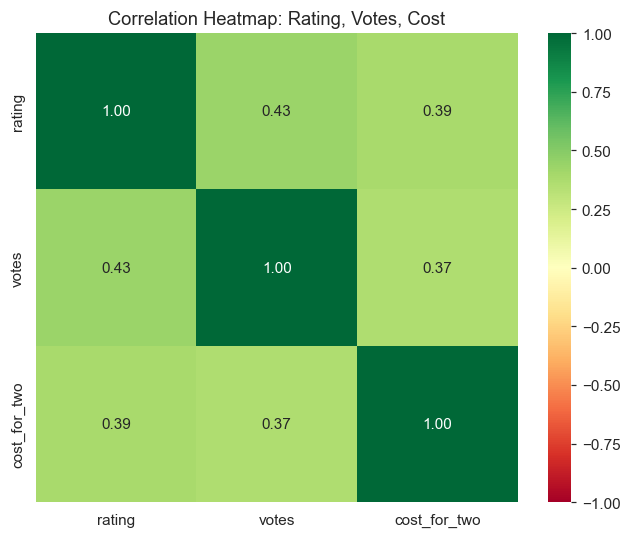

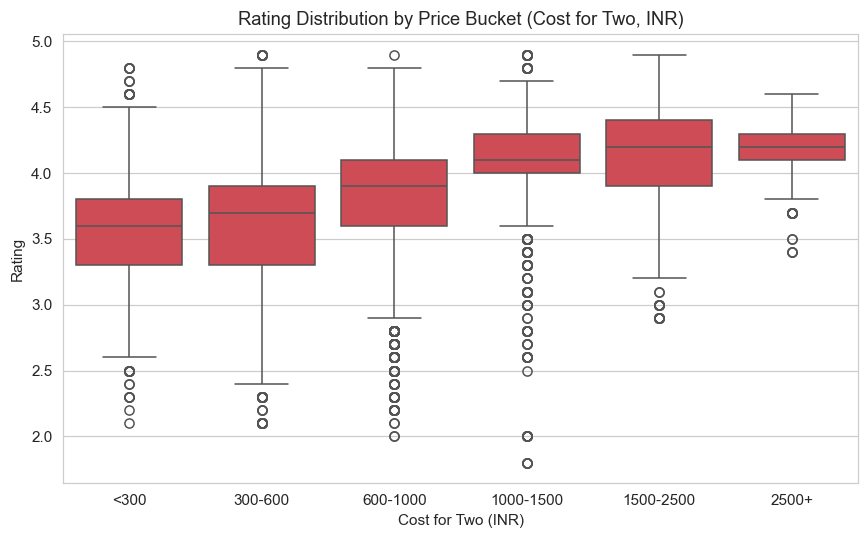

In [9]:
corr = df_rated[["rating", "votes", "cost_for_two"]].corr()
print("Correlation matrix:\n", corr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdYlGn", vmin=-1, vmax=1, ax=ax, fmt=".2f")
ax.set_title("Correlation Heatmap: Rating, Votes, Cost")
plt.tight_layout()
plt.savefig("corr_heatmap.png")
plt.show()

# Price bucket vs rating
df_rated["cost_bucket"] = pd.cut(df_rated["cost_for_two"], bins=[0, 300, 600, 1000, 1500, 2500, 10000], labels=["<300", "300-600", "600-1000", "1000-1500", "1500-2500", "2500+"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_rated, x="cost_bucket", y="rating", ax=ax, color="#e23744")
ax.set_title("Rating Distribution by Price Bucket (Cost for Two, INR)")
ax.set_xlabel("Cost for Two (INR)")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.savefig("price_vs_rating.png")
plt.show()

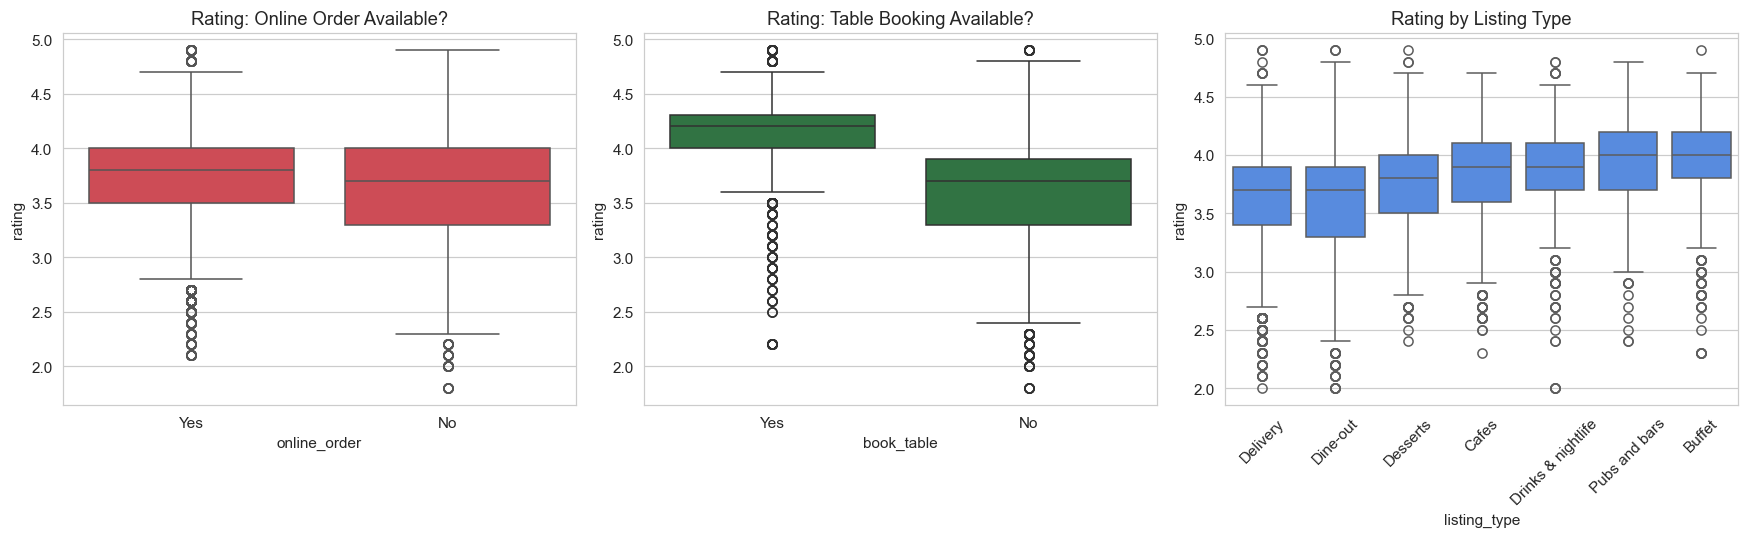

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_rated, x="online_order", y="rating", ax=axes[0], color="#e23744")
axes[0].set_title("Rating: Online Order Available?")

sns.boxplot(data=df_rated, x="book_table", y="rating", ax=axes[1], color="#267e3e")
axes[1].set_title("Rating: Table Booking Available?")

listing_order = df_rated.groupby("listing_type")["rating"].mean().sort_values().index
sns.boxplot(data=df_rated, x="listing_type", y="rating", ax=axes[2], order=listing_order, color="#4285F4")
axes[2].set_title("Rating by Listing Type")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("other_factors_vs_rating.png")
plt.show()

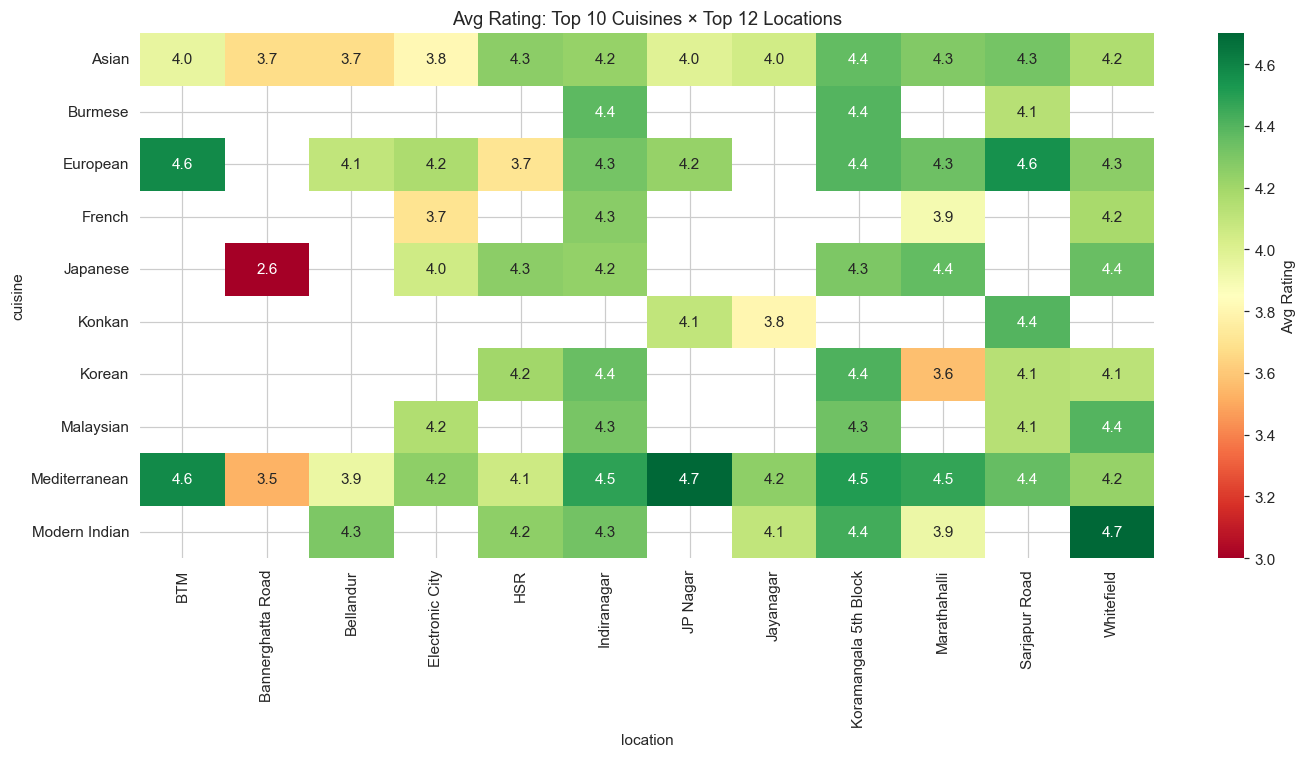

In [11]:
TOP_N_CUISINES = 10
TOP_N_LOCATIONS = 12

top_cuisines = cuisine_stats.head(TOP_N_CUISINES).index.tolist()
top_locations = location_stats.head(TOP_N_LOCATIONS).index.tolist()

pivot_data = cuisine_long[cuisine_long["cuisine"].isin(top_cuisines) & cuisine_long["location"].isin(top_locations)]

pivot = pivot_data.pivot_table(index="cuisine", columns="location", values="rating", aggfunc="mean")

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", vmin=3, vmax=4.7, ax=ax, cbar_kws={"label": "Avg Rating"})
ax.set_title(f"Avg Rating: Top {TOP_N_CUISINES} Cuisines × Top {TOP_N_LOCATIONS} Locations")
plt.tight_layout()
plt.savefig("cuisine_location_heatmap.png")
plt.show()

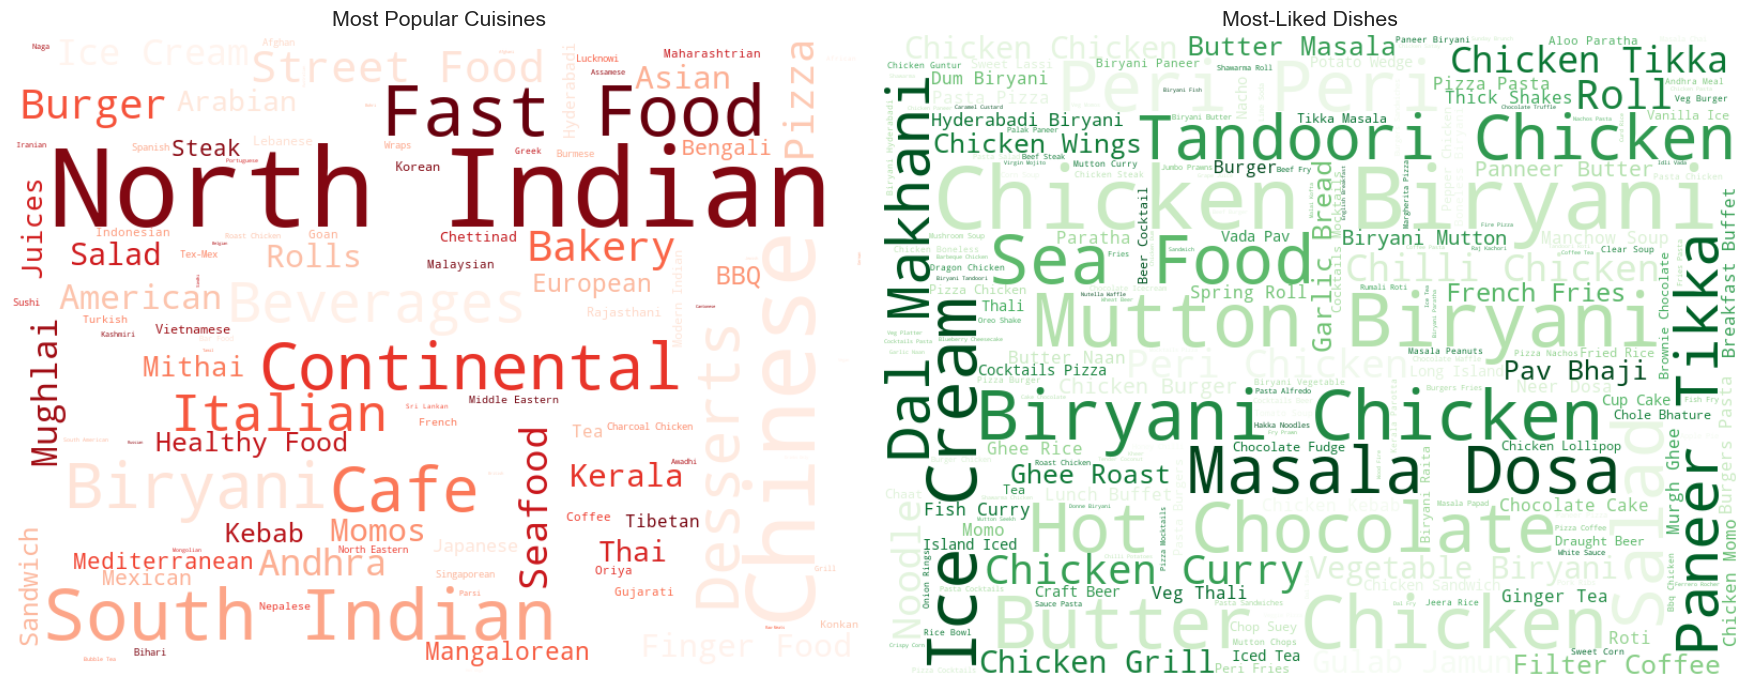

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Cuisine popularity wordcloud (weighted by number of listings)
cuisine_freq = cuisine_long["cuisine"].value_counts().to_dict()
wc_cuisine = WordCloud(width=800, height=600, background_color="white", colormap="Reds").generate_from_frequencies(cuisine_freq)
axes[0].imshow(wc_cuisine, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Most Popular Cuisines", fontsize=14)

dish_text = " ".join(df_rated["dish_liked"].dropna().str.replace(",", " "))
wc_dish = WordCloud(width=800, height=600, background_color="white", colormap="Greens").generate(dish_text)
axes[1].imshow(wc_dish, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Most-Liked Dishes", fontsize=14)

plt.tight_layout()
plt.savefig("wordclouds.png")
plt.show()

In [13]:
recommendations = [
    (
        "Localized 'Hotspot' Partnership Packages",
        f"Concentrate merchant-acquisition and sponsored-placement efforts on "
        f"the top restaurant-dense neighborhoods (e.g. {', '.join(location_stats.head(5).index)}). "
        f"These areas have the deepest restaurant supply and the most price/rating "
        f"variance — the highest-value real estate for featured listings and "
        f"neighborhood-level ad packages."
    ),
    (
        "Cuisine-Based Content & Curated Collections",
        f"Build recurring editorial content ('Best {cuisine_stats.index[0]} Under "
        f"₹500', 'Top-Rated {cuisine_stats.index[1]} Spots') around the "
        f"highest-rated, highest-demand cuisines identified in the cuisine "
        f"analysis. This drives organic search traffic and gives restaurants "
        f"a reason to keep their listings current."
    ),
    (
        "Reward Online-Ordering & Table-Booking Adoption",
        "Since restaurants offering online ordering and table booking show "
        "higher median ratings, incentivize non-adopting restaurants (discounted "
        "onboarding fees, visibility boosts) to enable these features — it's a "
        "lever that correlates with better customer experience, not just convenience."
    ),
    (
        "Price-Tier Discovery Filters, Not Just Price Sorting",
        "Since cost only weakly predicts rating, help users find 'hidden gem' "
        "budget restaurants with high ratings rather than assuming higher price "
        "= better quality. A 'Best Value' filter (high rating, low cost bucket) "
        "would differentiate the platform from pure price-sort competitors."
    ),
    (
        "Fix Structured Review Capture at the Data Layer",
        "This raw dataset shows what happens when free-text reviews aren't "
        "captured in clean, structured fields — 8% of records were unusable "
        "due to quoting/escaping corruption. A platform should store review "
        "text, sub-ratings (taste/service/ambience), and dish mentions as "
        "separate structured fields from day one — enabling exactly the "
        "sentiment analysis and dish-level wordclouds this dataset couldn't support."
    ),
]

for i, (title, body) in enumerate(recommendations, 1):
    print(f"{i}. {title}\n   {body}\n")

1. Localized 'Hotspot' Partnership Packages
   Concentrate merchant-acquisition and sponsored-placement efforts on the top restaurant-dense neighborhoods (e.g. Whitefield, BTM, HSR, Marathahalli, Electronic City). These areas have the deepest restaurant supply and the most price/rating variance — the highest-value real estate for featured listings and neighborhood-level ad packages.

2. Cuisine-Based Content & Curated Collections
   Build recurring editorial content ('Best Modern Indian Under ₹500', 'Top-Rated Malaysian Spots') around the highest-rated, highest-demand cuisines identified in the cuisine analysis. This drives organic search traffic and gives restaurants a reason to keep their listings current.

3. Reward Online-Ordering & Table-Booking Adoption
   Since restaurants offering online ordering and table booking show higher median ratings, incentivize non-adopting restaurants (discounted onboarding fees, visibility boosts) to enable these features — it's a lever that correlat

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Keep only rows with everything we need for modeling
df_model = df_rated.dropna(subset=["location", "rest_type", "cuisines", "listing_type", "votes", "cost_for_two"]).copy()

TOP_N_LOC, TOP_N_REST, TOP_N_CUIS = 20, 15, 15

# Cap high-cardinality categoricals to top-N + "Other" so one-hot encoding stays manageable
top_locs = df_model["location"].value_counts().head(TOP_N_LOC).index
df_model["location_grp"] = df_model["location"].where(df_model["location"].isin(top_locs), "Other")

top_rest = df_model["rest_type"].value_counts().head(TOP_N_REST).index
df_model["rest_type_grp"] = df_model["rest_type"].where(df_model["rest_type"].isin(top_rest), "Other")

# Cuisines are multi-valued -> multi-hot encode the top N
cui_dummies = df_model["cuisines"].str.get_dummies(sep=", ")
top_cuis = cui_dummies.sum().sort_values(ascending=False).head(TOP_N_CUIS).index
cui_dummies = cui_dummies[top_cuis].add_prefix("cuisine_")

X_num = df_model[["votes", "cost_for_two"]].reset_index(drop=True)
X_bin = pd.DataFrame({"online_order": (df_model["online_order"] == "Yes").astype(int), "book_table": (df_model["book_table"] == "Yes").astype(int), }).reset_index(drop=True)
X_cat = pd.get_dummies(df_model[["location_grp", "rest_type_grp", "listing_type"]], drop_first=True).reset_index(drop=True)

X = pd.concat([X_num, X_bin, X_cat, cui_dummies.reset_index(drop=True)], axis=1)
y = df_model["rating"].reset_index(drop=True)

print("Feature matrix:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: Linear Regression
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Main model: Random Forest (handles non-linear effects + interactions)
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2":   [r2_score(y_test, pred_lr), r2_score(y_test, pred_rf)],
    "MAE":  [mean_absolute_error(y_test, pred_lr), mean_absolute_error(y_test, pred_rf)],
    "RMSE": [mean_squared_error(y_test, pred_lr) ** 0.5, mean_squared_error(y_test, pred_rf) ** 0.5],
})
print(results.round(3))

Feature matrix: (36957, 60)
               Model     R2    MAE   RMSE
0  Linear Regression  0.330  0.263  0.335
1      Random Forest  0.685  0.160  0.230


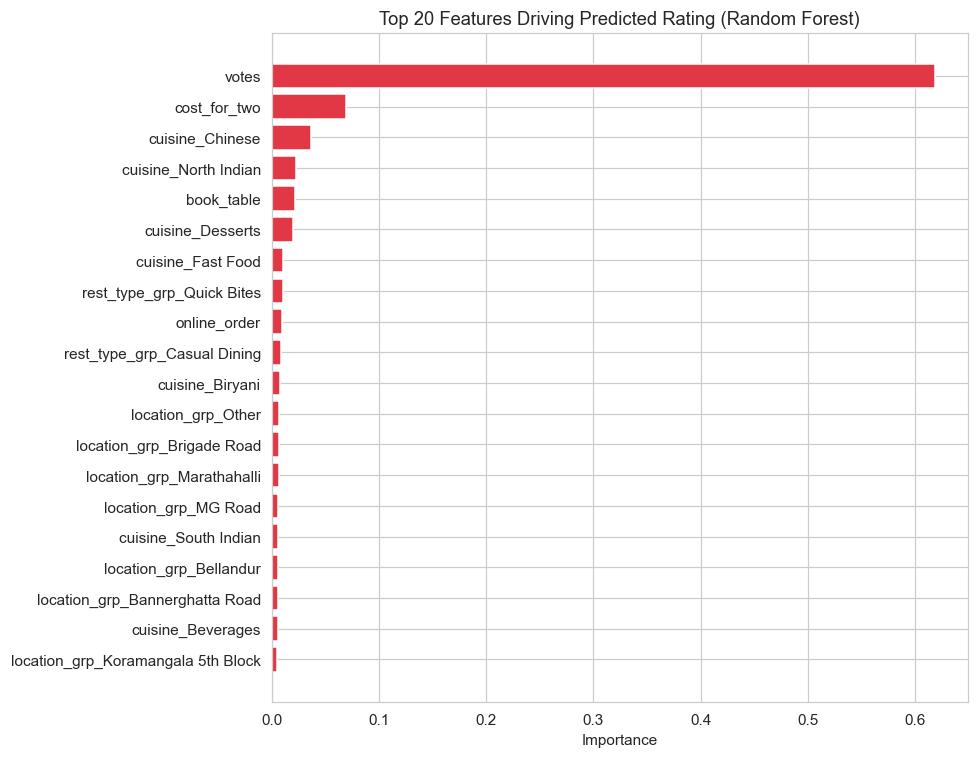

Top 10 drivers of rating:
votes                          0.618392
cost_for_two                   0.068971
cuisine_Chinese                0.036630
cuisine_North Indian           0.022982
book_table                     0.022119
cuisine_Desserts               0.019585
cuisine_Fast Food              0.010869
rest_type_grp_Quick Bites      0.010422
online_order                   0.009570
rest_type_grp_Casual Dining    0.009226
dtype: float64


In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top20 = importances.head(20).sort_values()
ax.barh(top20.index, top20.values, color="#e23744")
ax.set_title("Top 20 Features Driving Predicted Rating (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print("Top 10 drivers of rating:")
print(importances.head(10))

In [16]:
key_findings = [
    f"Of {len(df_raw):,} raw rows, {len(df):,} were usable after removing "
    f"{(~row_is_clean).sum():,} rows corrupted by broken CSV quoting "
    f"({(~row_is_clean).mean():.1%} of the file).",

    f"{cuisine_stats.index[0]} is the top-rated major cuisine "
    f"(avg {cuisine_stats.iloc[0]['avg_rating']:.2f}/5, "
    f"{int(cuisine_stats.iloc[0]['n_listings'])} listings), while "
    f"{cuisine_stats.index[-1]} rates lowest among common cuisines "
    f"(avg {cuisine_stats.iloc[-1]['avg_rating']:.2f}/5).",

    f"North Indian, Chinese and South Indian are the three most widely "
    f"offered cuisines by listing volume.",

    f"{location_stats.index[0]} has the most restaurants "
    f"({int(location_stats.iloc[0]['n_restaurants']):,}), making it the "
    f"single biggest hotspot in the dataset.",

    f"Cost for two correlates positively with rating (r = {corr.loc['rating','cost_for_two']:.2f}) "
    f"— pricier restaurants trend modestly higher-rated, but it's a weak "
    f"relationship, not a strong driver.",

    f"Votes correlate more strongly with rating (r = {corr.loc['rating','votes']:.2f}) "
    f"than cost does — popularity/engagement tracks rating more than price does.",

    f"Restaurants offering online ordering and table booking both show "
    f"visibly higher median ratings than those that don't, in the boxplots above.",

    f"A Random Forest model predicting rating from votes, cost, location, "
    f"cuisine, rest type and listing type achieves R\u00b2 = {r2_score(y_test, pred_rf):.2f} "
    f"(vs. {r2_score(y_test, pred_lr):.2f} for plain Linear Regression). "
    f"'{importances.index[0]}' alone accounts for "
    f"{importances.iloc[0]:.0%} of feature importance — engagement/popularity "
    f"predicts rating far more than cuisine, price, or location do.",
]

for i, f_ in enumerate(key_findings, 1):
    print(f"{i}. {f_}\n")

1. Of 56,252 raw rows, 51,717 were usable after removing 4,535 rows corrupted by broken CSV quoting (8.1% of the file).

2. Modern Indian is the top-rated major cuisine (avg 4.31/5, 145 listings), while Hyderabadi rates lowest among common cuisines (avg 3.52/5).

3. North Indian, Chinese and South Indian are the three most widely offered cuisines by listing volume.

4. Whitefield has the most restaurants (631), making it the single biggest hotspot in the dataset.

5. Cost for two correlates positively with rating (r = 0.39) — pricier restaurants trend modestly higher-rated, but it's a weak relationship, not a strong driver.

6. Votes correlate more strongly with rating (r = 0.43) than cost does — popularity/engagement tracks rating more than price does.

7. Restaurants offering online ordering and table booking both show visibly higher median ratings than those that don't, in the boxplots above.

8. A Random Forest model predicting rating from votes, cost, location, cuisine, rest type 

In [42]:
with PdfPages("zomato_analysis_report.pdf") as pdf:

    # --- Title page
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    fig.text(0.5, 0.7, "Zomato Restaurant Data Analysis", ha="center", fontsize=22, weight="bold")
    fig.text(0.5, 0.63, "Ratings, Cuisines, Location & Pricing Insights", ha="center", fontsize=14)
    fig.text(0.5, 0.55, f"Dataset: {RAW_PATH}  |  {len(df):,} clean records analyzed", ha="center", fontsize=10)
    plt.axis("off")
    pdf.savefig(fig); plt.close(fig)

    # --- Key findings page
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.08, 0.95, "Key Findings", fontsize=18, weight="bold")
    y = 0.88
    for f_ in key_findings:
        fig.text(0.08, y, f"• {f_}", fontsize=10, wrap=True, va="top")
        y -= 0.11
    plt.axis("off")
    pdf.savefig(fig); plt.close(fig)

    # Model results page
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.08, 0.95, "Predictive Model: What Drives Rating?", 
             fontsize=16, weight="bold")

    # Model performance table
    ax = fig.add_axes([0.08, 0.68, 0.55, 0.18])
    ax.axis('off')
    table_data = results.round(3).reset_index()
    table = ax.table(cellText=table_data.values,
                     colLabels=table_data.columns,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)

    # Feature importances
    fig.text(0.08, 0.52, "Top 10 Feature Importances (Random Forest):", 
             fontsize=11, weight="bold")

    imp_text = importances.head(10).round(3).to_string()
    fig.text(0.08, 0.50, imp_text, fontsize=10, family="monospace", va="top")

    plt.axis("off")
    pdf.savefig(fig)
    plt.close(fig)
    
    # Recommendations page
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.08, 0.95, "Recommendations for Alfido Tech-style Platform", fontsize=16, weight="bold")
    y = 0.88
    for i, (title, body) in enumerate(recommendations, 1):
        fig.text(0.08, y, f"{i}. {title}", fontsize=11, weight="bold", va="top")
        y -= 0.035
        fig.text(0.1, y, body, fontsize=9, wrap=True, va="top")
        y -= 0.14
    plt.axis("off")
    pdf.savefig(fig); plt.close(fig)

    # Charts (re-open each saved PNG as a page)
    for img_path, caption in [
        ("cuisine_vs_rating.png", "Cuisine vs Rating"),
        ("location_hotspots.png", "Location Hotspots"),
        ("corr_heatmap.png", "Correlation Heatmap"),
        ("price_vs_rating.png", "Price vs Rating"),
        ("other_factors_vs_rating.png", "Other Rating Factors"),
        ("cuisine_location_heatmap.png", "Cuisine x Location Heatmap"),
        ("wordclouds.png", "Cuisine & Dish Wordclouds"),
    ]:
        img = plt.imread(img_path)
        fig, ax = plt.subplots(figsize=(8.27, 11.69))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(caption, fontsize=14, weight="bold")
        pdf.savefig(fig); plt.close(fig)

print("Saved: zomato_analysis_report.pdf")

Saved: zomato_analysis_report.pdf
